In [20]:
import numpy as np
import numpy.linalg as la
from itertools import combinations
from scipy.linalg import toeplitz
from collections import Counter
################################################

from numpy import cos, sin, atan2,pi,exp
import matplotlib.pyplot as plt

In [169]:
def theta(k,g):
    return atan2(sin(k),(g-cos(k)))

def aa(k,g):
    th = theta(k,g)
    return - cos(th/2)**2

def cc(k,g):
    th = theta(k,g)
    return sin(th/2)**2

def ac(k,g):
    th = theta(k,g)
    return 1j*cos(th/2)*sin(th/2)

def ca(k,g):
    th = theta(k,g)
    return -1j*cos(th/2)*sin(th/2)



def AA(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)

    return -aa(k,g)*(phase-phase_i)

def CC(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)
    return cc(k,g)*(phase-phase_i)

def AC(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r)
    return ac(k,g)*phase_i - ac(-k,g)*phase

def CA(r,g,k):
    phase = exp(1j*k*r)
    phase_i = exp(-1j*k*r) 
    return ca(k,g)*phase-ca(-k,g)*phase_i

def BA(r,g,k):

    return -AC(r,g,k)-AA(r,g,k)+CC(r,g,k)+CA(r,g,k)

In [170]:
k = np.linspace(-pi,pi,100)

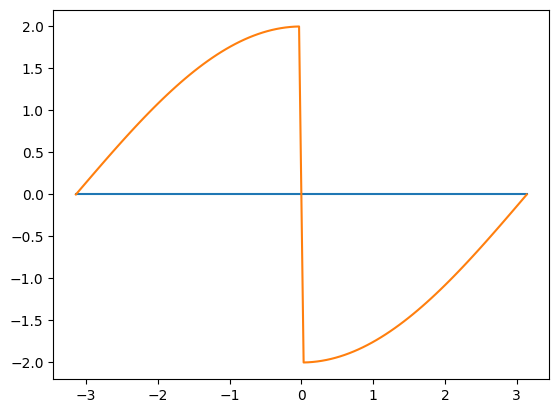

In [171]:
args = (0,1,k)
x = -AA(*args)+CC(*args)+CA(*args)-AC(*args)
plt.plot(k,np.real(x))
plt.plot(k,np.imag(x))

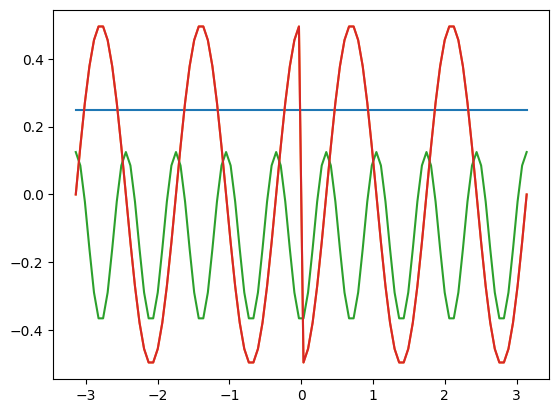

In [174]:
args = (5,1,k)
x =(1+ BA(*args))/4
d = BA(*args)
y = (1+2*d+d*d)/8
plt.plot(k,np.real(x))
plt.plot(k,np.imag(x))

plt.plot(k,np.real(y))
plt.plot(k,np.imag(y))

In [228]:

def sigma_general(indices,g,k):
    def remove_duplicates_in_pairs(vec):
      unique_vals, counts = np.unique(vec, return_counts=True)
      filtered_vals = unique_vals[counts % 2 != 0]
      return filtered_vals.tolist()
    #Sigma matrices on different sites commute
    indices = np.sort(indices)
    #Remove any duplicates as sigma_x^2 = 1
    indices = remove_duplicates_in_pairs(indices)
    #Bs sit on odd sites
    odd_sites = np.array(indices[::2])
    #As site on even sites
    even_sites= np.array(indices[1::2])
    #Get string lengths
    JW_string_lengths = even_sites-odd_sites
    #Sum of string lengths is size of matrix needed
    N = sum(JW_string_lengths)
    #Fill in indices for strings
    R = []
    for i in range(0, len(indices), 2):
        start = indices[i]
        end = indices[i+1]
        R.extend(range(start, end+1))

    A_coords = [x for x in R if x not in odd_sites]
    B_coords = [x for x in R if x not in even_sites]
    C = np.zeros((N,N),dtype=complex)
    for nx in range(N):
        for ny in range(N):
            Bx = B_coords[nx]
            Ay = A_coords[ny]
            Nd = Bx-Ay+1
            C[nx,ny] = BA(Nd,g,k)
    return np.linalg.det(C)



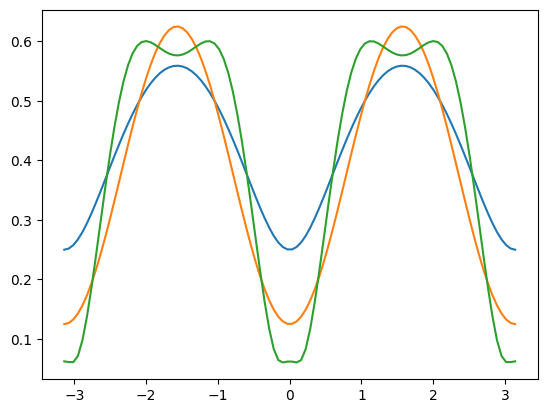

In [229]:
g = 0
x = np.array([ sigma_general([0,1],g,ki) for ki in k])
y =  np.array([ sigma_general([0,2],g,ki) for ki in k])
z= np.array([ sigma_general([0,3],g,ki) for ki in k])
w= np.array([ sigma_general([0,1,2,3],g,ki) for ki in k])

x1 = (1+x)/4
x2 = (1+2*x+y)/8
x3 = (8*x2+y+x+z+w)/16

plt.plot(k,np.abs(x1))
plt.plot(k,np.abs(x2))
plt.plot(k,np.abs(x3))

In [230]:

################################################
#                X PROJECTORS
################################################

def binomial_expansion(indices):
    """
    Computes the pairs of combinations of indices.
    """
    pairs = list(combinations(indices, 2))
    return pairs

def all_combinations(indices):
    """
    Computes all combinations of all lengths of indices.
    """
    x = []
    for r in range(len(indices) + 1):
        x.extend(combinations(indices, r))
    return list(x)

def unique_elements_and_frequencies(vec):
    unique_vals, freqs = np.unique(vec, return_counts=True)
    return unique_vals, freqs


def P_n(n,g,k, even = True):
    """
    P_n scales directly with the number of terms since even small odd sigma correlations need larger support to calcualte.
    Taking out odd terms works to make easier, but scaling is still 2^n.
    Minor improvements can still be had though.
    """
    #For most cases we use periodic boundary conditions
    #That said, watch out for this definition of indices
    indices = [i for i in range(0,n)]
    terms = all_combinations(indices)

    ###
    x_c = []
    for a in terms[1:]:
      
        a = np.array(a)
        x_c.append(tuple(a - a[0]))  # convert to tuple for hashing
    counter = Counter(x_c)

    # Extract vecs and counts as separate arrays/lists
    vecs = list(counter.keys())
    counts = np.array(list(counter.values()))

    ##
    dat = []

    for term in range(len(vecs)):
        indices = vecs[term]
        degen = counts[term]

        if len(indices)%2 == 1:
            if even ==True:
                dat.append(0)
            else:
                constant = len(k)//2
                indices = list(indices) + [x + constant for x in indices]
                dat.append(np.sqrt(np.abs(sigma_general(indices,g,k)))*degen)
        else:
            dat.append(sigma_general(indices,g,k)*degen)
   # dat.append(1)
    #All terms have equal weight. 
    return np.sum(dat)/2**n



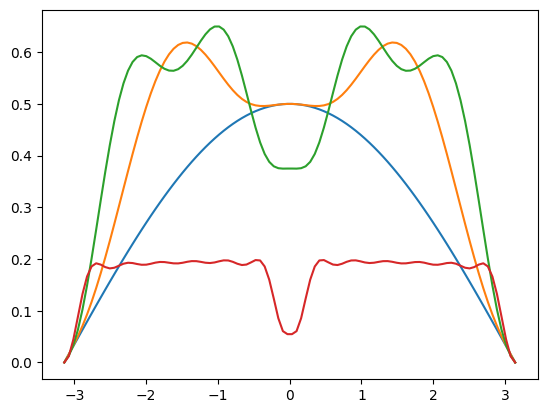

In [263]:
g= 1
plt.plot(k,np.array([np.abs(P_n(2,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(3,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(4,g,ki)) for ki in k]))
plt.plot(k,np.array([np.abs(P_n(8,g,ki)) for ki in k]))

In [241]:
sigma_general([0,1],1,2)

np.complex128(-1.0806046117362795j)